In [1]:
!pip install tensorflow
!pip install pandas
!pip install numpy

**Load Dataset**

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Download the MovieLens dataset
!wget http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -o ml-latest-small.zip
# Load the dataset into a Pandas DataFrame
ratings = pd.read_csv('ml-latest-small/ratings.csv')
# Display the first few rows of the dataset
ratings.head()

--2026-07-15 10:48:49--  http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-latest-small.zip [following]
--2026-07-15 10:48:50--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  --.-KB/s    in 0.1s    

2026-07-15 10:48:51 (6.46 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.c

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


**Pre Processing Data**

In [3]:
# Map user IDs and item IDs to a continuous range
user_ids = ratings['userId'].astype('category').cat.codes.values
item_ids = ratings['movieId'].astype('category').cat.codes.values
ratings['user_id'] = user_ids
ratings['item_id'] = item_ids
# Prepare train and test data
train, test = train_test_split(ratings, test_size=0.2, random_state=42)
# Extract user IDs, item IDs, and labels for training and testing
train_user_ids = train['user_id'].values
train_item_ids = train['item_id'].values
train_labels = (train['rating'] >= 4).astype(int).values # Consider ratings >= 4 as positive interaction
test_user_ids = test['user_id'].values
test_item_ids = test['item_id'].values
test_labels = (test['rating'] >= 4).astype(int).values

**Define the NCF Model**

In [4]:
num_users = ratings['user_id'].nunique()
num_items = ratings['item_id'].nunique()
embedding_size = 50
hidden_units = [128, 64, 32]
dropout_rate = 0.2
# Input layers
user_input = Input(shape=(1,), name='user_input')
item_input = Input(shape=(1,), name='item_input')
# Embedding layers
user_embedding = Embedding(num_users, embedding_size, name='user_embedding')(user_input)
item_embedding = Embedding(num_items, embedding_size, name='item_embedding')(item_input)
# Flatten the embeddings
user_flatten = Flatten()(user_embedding)
item_flatten = Flatten()(item_embedding)
# Concatenate embeddings for MLP
concat = Concatenate()([user_flatten, item_flatten])
# MLP layers
mlp = Dense(hidden_units[0], activation='relu')(concat)
mlp = Dropout(dropout_rate)(mlp)
mlp = Dense(hidden_units[1], activation='relu')(mlp)
mlp = Dropout(dropout_rate)(mlp)
mlp = Dense(hidden_units[2], activation='relu')(mlp)
# Final output layer
output = Dense(1, activation='sigmoid')(mlp)
# Define the model
model = Model(inputs=[user_input, item_input], outputs=output)
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
# Display the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │     30,500 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 50)     │    486,200 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 539,997 (2.06 MB)

 Trainable params: 539,997 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

**Train the Model**

In [5]:
# Train the model
history = model.fit([train_user_ids, train_item_ids], train_labels, batch_size=64, epochs=10, validation_split=0.1)

Epoch 1/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6841 - loss: 0.5889 - val_accuracy: 0.7044 - val_loss: 0.5645
Epoch 2/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.7368 - loss: 0.5233 - val_accuracy: 0.7061 - val_loss: 0.5638
Epoch 3/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7576 - loss: 0.4879 - val_accuracy: 0.7048 - val_loss: 0.5821
Epoch 4/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7782 - loss: 0.4569 - val_accuracy: 0.6983 - val_loss: 0.6017
Epoch 5/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8000 - loss: 0.4201 - val_accuracy: 0.6903 - val_loss: 0.6441
Epoch 6/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8205 - loss: 0.3811 - val_accuracy: 0.6855 - val_loss: 0.7101
Epoch 7/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8415 - loss: 0.3409 - val_accuracy: 0.6848 - val_loss: 0.7588
Epoch 8/10
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8576 - loss

**Evaluate the Model**

In [6]:
# Evaluate the model
loss, accuracy = model.evaluate([test_user_ids, test_item_ids], test_labels)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')
# Make predictions
user_id = np.array([1])
item_id = np.array([1])
rediction = model.predict([user_id, item_id])
print(f'Prediction for user {user_id[0]} and item {item_id[0]}: {rediction[0][0]}')

631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6816 - loss: 0.9790
Test Loss: 0.9790385961532593, Test Accuracy: 0.6816243529319763
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Prediction for user 1 and item 1: 0.271974116563797


**Visualize Training History**

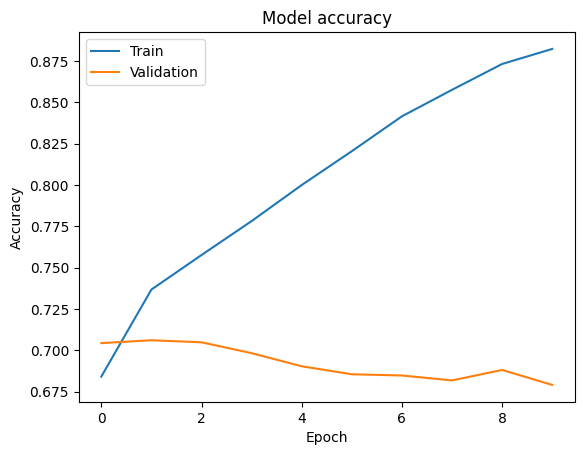

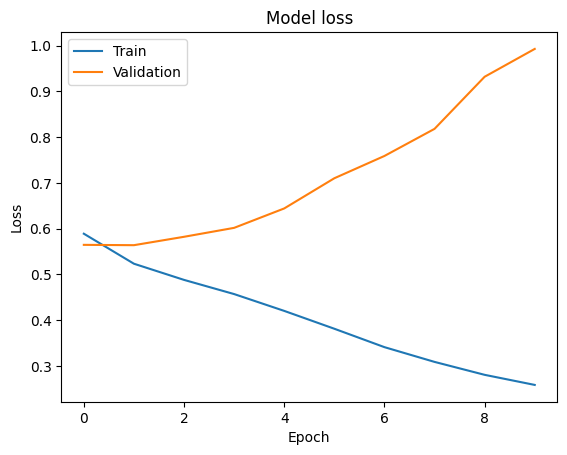

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


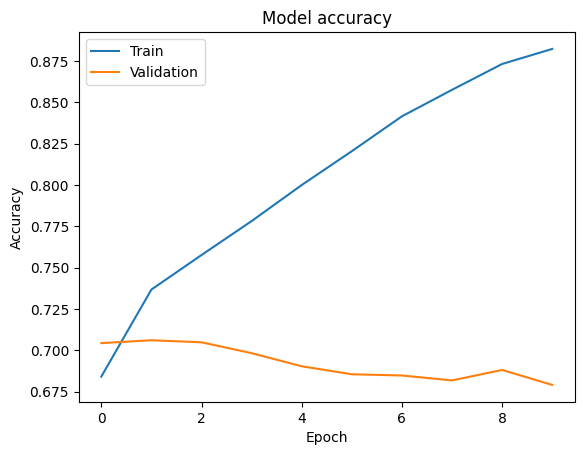

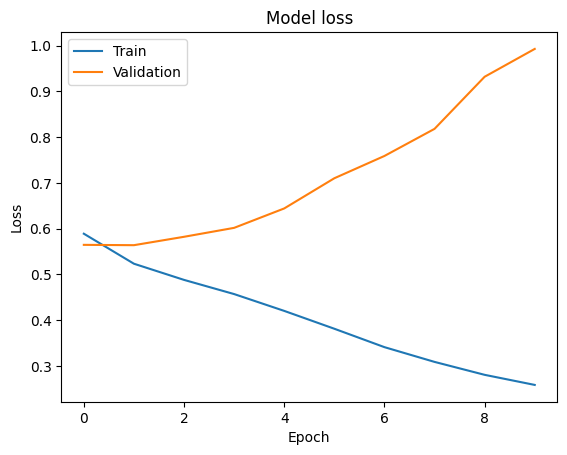

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Load the movies data**

In [9]:
movies = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/movies.csv')
# Display the first few rows of the movies dataset
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
# Merge the ratings and movies data on the movieId
ratings = ratings.merge(movies, on='movieId')
# Display the merged dataset with user and movie names
ratings.head()

,userId,movieId,rating,timestamp,user_id,item_id,title,genres
0,1,1,4.0,964982703,0,0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,0,2,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,0,5,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,0,43,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,0,46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [11]:
# Function to get valid user IDs, item IDs, and their names
def get_valid_ids_with_names():
    user_id_name_mapping = {user_id: f'User {user_id}' for user_id in ratings['userId'].unique()}
    item_id_name_mapping = {row['movieId']: row['title'] for _, row in movies.iterrows()}
    return user_id_name_mapping, item_id_name_mapping
# Function to prompt for and validate user input with names
def prompt_for_input_with_names(user_id_name_mapping, item_id_name_mapping):
    while True:
        try:
            user_id = int(input(f"Enter a user ID from the following list: {list(user_id_name_mapping.keys())[:10]}: "))
            if user_id not in user_id_name_mapping:
                print(f"User ID {user_id} is not valid. Please enter a valid user ID.")
                continue
            item_id = int(input(f"Enter a movie ID from the following list: {list(item_id_name_mapping.keys())[:10]}: "))
            if item_id not in item_id_name_mapping:
                print(f"Movie ID {item_id} is not valid. Please enter a valid movie ID.")
                continue
            return user_id, item_id
        except ValueError:
            print("Invalid input. Please enter integer values for user ID and movie ID.")
# Get valid user IDs, item IDs, and their names
user_id_name_mapping, item_id_name_mapping = get_valid_ids_with_names()
# Prompt for user input
user_id, item_id = prompt_for_input_with_names(user_id_name_mapping, item_id_name_mapping)
# Predict the interaction score
user_id_array = np.array([user_id])
item_id_array = np.array([item_id])
prediction = model.predict([user_id_array, item_id_array])
print(f'Prediction for {user_id_name_mapping[user_id]} and {item_id_name_mapping[item_id]}: {prediction[0][0]}')

Enter a user ID from the following list: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]: 1
Enter a movie ID from the following list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction for User 1 and Jumanji (1995): 0.09815219789743423


In [12]:
# Predefined user and item IDs for testing (use actual IDs from the dataset)
test_user_id = 1 # Replace with a valid user ID
test_item_id = 1 # Replace with a valid movie ID
user_name = f"User {test_user_id}"
movie_name = movies[movies['movieId'] == test_item_id]['title'].values[0]
# Predict the interaction score for predefined IDs
user_id_array = np.array([test_user_id])
item_id_array = np.array([test_item_id])
prediction = model.predict([user_id_array, item_id_array])
print(f'Prediction for {user_name} and "{movie_name}": {prediction[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction for User 1 and "Toy Story (1995)": 0.271974116563797
